## Tiền xử lý dữ liệu
Dữ liệu đầu vào gồm các features, đầu tiên cần hiểu rõ các cột này mang ý nghĩa gì:  
-HeartDisease : Có bệnh tim hay không ( cột cần dự đoán)  
**Nhóm chỉ số số học :**  
-BMI : Chỉ số khối cơ thể  
-PhysicalHealth:Số ngày sức khỏe thể chất không tốt trong 30 ngày gần nhất  
-MentalHealth:Số ngày sức khỏe tinh thần không tốt trong 30 ngày gần nhất  
-SleepTime:Số giờ ngủ trung bình mỗi ngày  
**Nhóm biến Yes/No :**  
-Smoking : Có hút thuốc không  
-AlcoholDrinking:Có uống rượu nhiều không  
-Stroke: Có từng bị đột quỵ không  
-DiffWalking: Có khó khăn khi đi bộ không  
-PhysicalActivity: Có hoạt động thể chất không  
-Asthma: Có hen suyễn không  
-KidneyDisease:Có bệnh thận không  
-SkinCancer:Có ung thư da không  
**Nhóm biến phân loại nhiều giá trị :**  
-Sex:Giới tính  
-AgeCategory:Nhóm tuổi  
-Race: Chủng tộc  
-Diabetic: Tình trạng tiểu đường  
-GenHealth:	Tự đánh giá sức khỏe tổng quát  



## Đọc thông tin và mô tả dữ liệu

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. Đọc dữ liệu
df = pd.read_csv("/content/heart_2020_cleaned.csv")
print(f"Kích thước ban đầu: {df.shape}")


# Phân loại cột
num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']


Kích thước ban đầu: (319795, 18)


Kiểm tra dữ liệu thiếu

Dữ liệu thiếu là các ô bị rỗng hoặc có giá trị NaN. Nếu dữ liệu có nhiều giá trị thiếu, ta cần xử lý bằng cách điền trung bình, trung vị, mode hoặc xóa dòng bị thiếu.

In [69]:
#3 : Kiểm tra số lượng giá trị thiếu ở từng cột
missing_values = df.isnull().sum()

print("Số giá trị thiếu theo từng cột:")
print(missing_values)

Số giá trị thiếu theo từng cột:
HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64


Kiểm tra và xử lý dữ liệu trùng lặp  
Dữ liệu trùng lặp là các dòng có thông tin giống hệt nhau. Nếu giữ lại các dòng trùng lặp, mô hình có thể học lệch vì một số mẫu xuất hiện nhiều lần.

In [70]:
# Xóa dòng trùng lặp
df = df.drop_duplicates()

# Đánh lại index
df = df.reset_index(drop=True)

print("Kích thước sau khi xóa trùng:", df.shape)

Kích thước sau khi xóa trùng: (301717, 18)


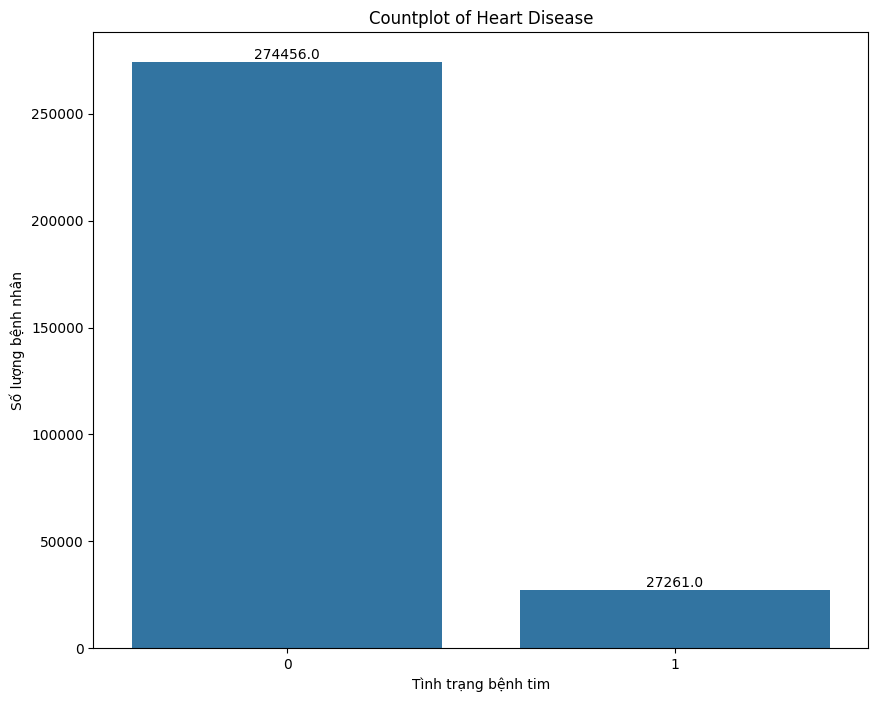

In [101]:
# Distribution of Target Variable
plt.figure(figsize = (10, 8))
ax = sns.countplot(x = 'HeartDisease', data = df)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')
plt.title("Countplot of Heart Disease")
plt.xlabel("Tình trạng bệnh tim")
plt.ylabel("Số lượng bệnh nhân")
plt.show()

## Trực quan hóa các biến số

--- TRỰC QUAN HÓA DỮ LIỆU GỐC ---


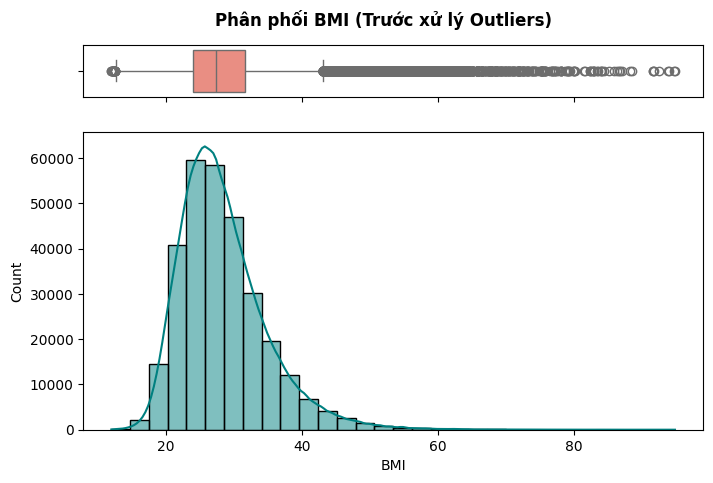

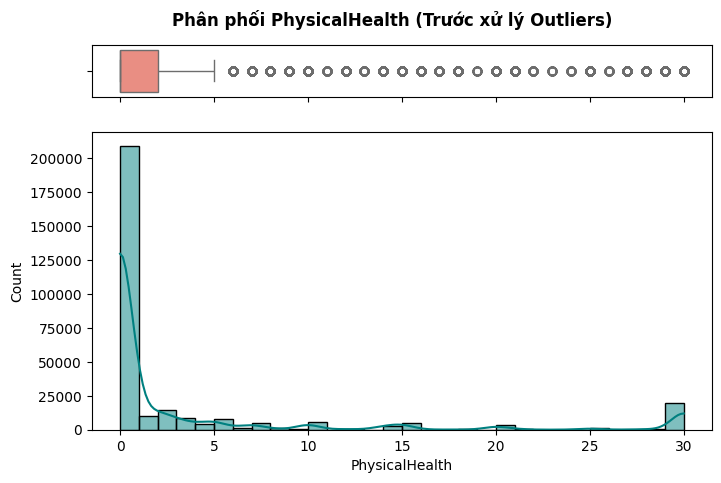

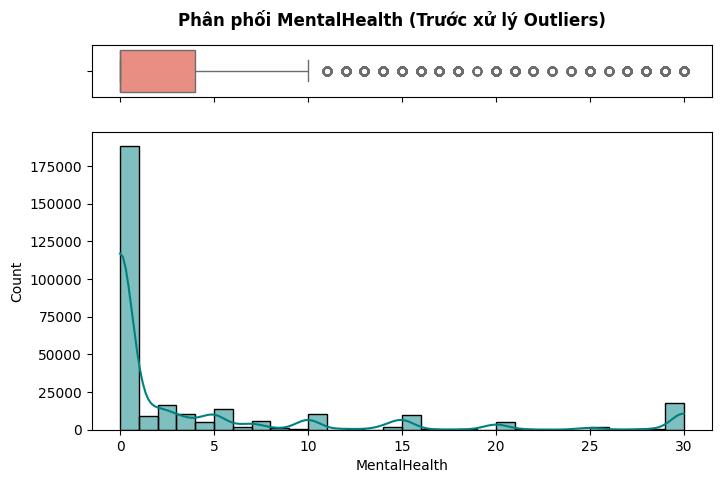

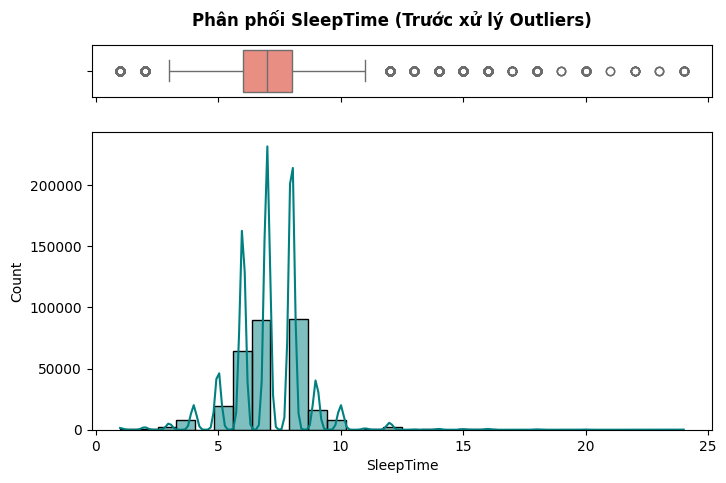

In [72]:
# Hàm vẽ biểu đồ thống nhất
def plot_unified(data, columns, title_suffix=""):
    for col in columns:
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(8, 5))

        sns.boxplot(x=data[col], ax=ax_box, color='salmon')
        ax_box.set(xlabel='')

        sns.histplot(data[col], ax=ax_hist, kde=True, color='teal', bins=30)

        plt.suptitle(f'Phân phối {col} {title_suffix}', y=0.95, fontweight='bold')
        plt.show()

# Vẽ cho dữ liệu gốc
print("--- TRỰC QUAN HÓA DỮ LIỆU GỐC ---")
plot_unified(df, num_cols, "(Trước xử lý Outliers)")

## Xử lý Outliers

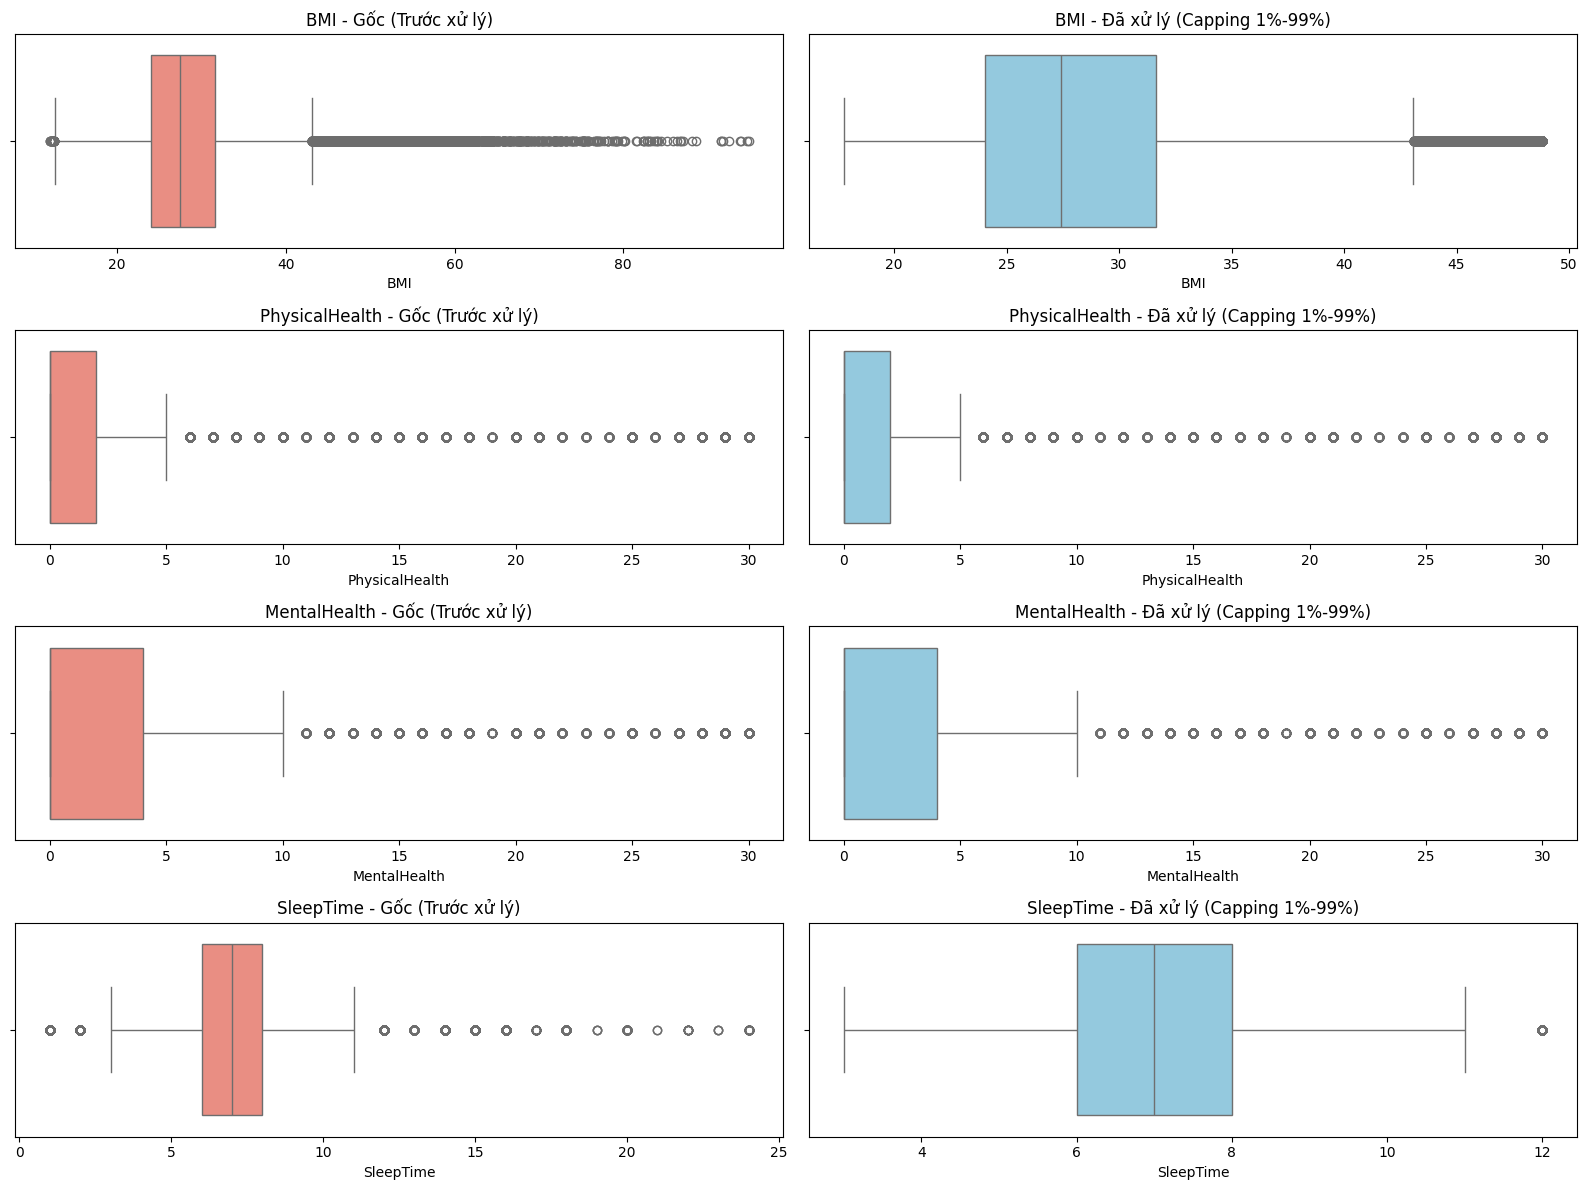

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chọn các cột số cần xử lý
num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

# 2. Thực hiện Capping (Winsorization)
df_cleaned = df.copy()
for col in num_cols:
    lower_limit = df[col].quantile(0.01) # Phân vị 1%
    upper_limit = df[col].quantile(0.99) # Phân vị 99%
    df_cleaned[col] = df_cleaned[col].clip(lower_limit, upper_limit)

# 3. Vẽ đồ thị so sánh (Ví dụ cho toàn bộ các cột)
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols):
    # Trước xử lý
    plt.subplot(4, 2, 2*i + 1)
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'{col} - Gốc (Trước xử lý)')

    # Sau xử lý
    plt.subplot(4, 2, 2*i + 2)
    sns.boxplot(x=df_cleaned[col], color='skyblue')
    plt.title(f'{col} - Đã xử lý (Capping 1%-99%)')

plt.tight_layout()
plt.show()

## Trực quan hóa các biến phân loại

/tmp/ipykernel_7210/3287391749.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
/tmp/ipykernel_7210/3287391749.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
/tmp/ipykernel_7210/3287391749.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
/tmp/ipykernel_7210/3287391749.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

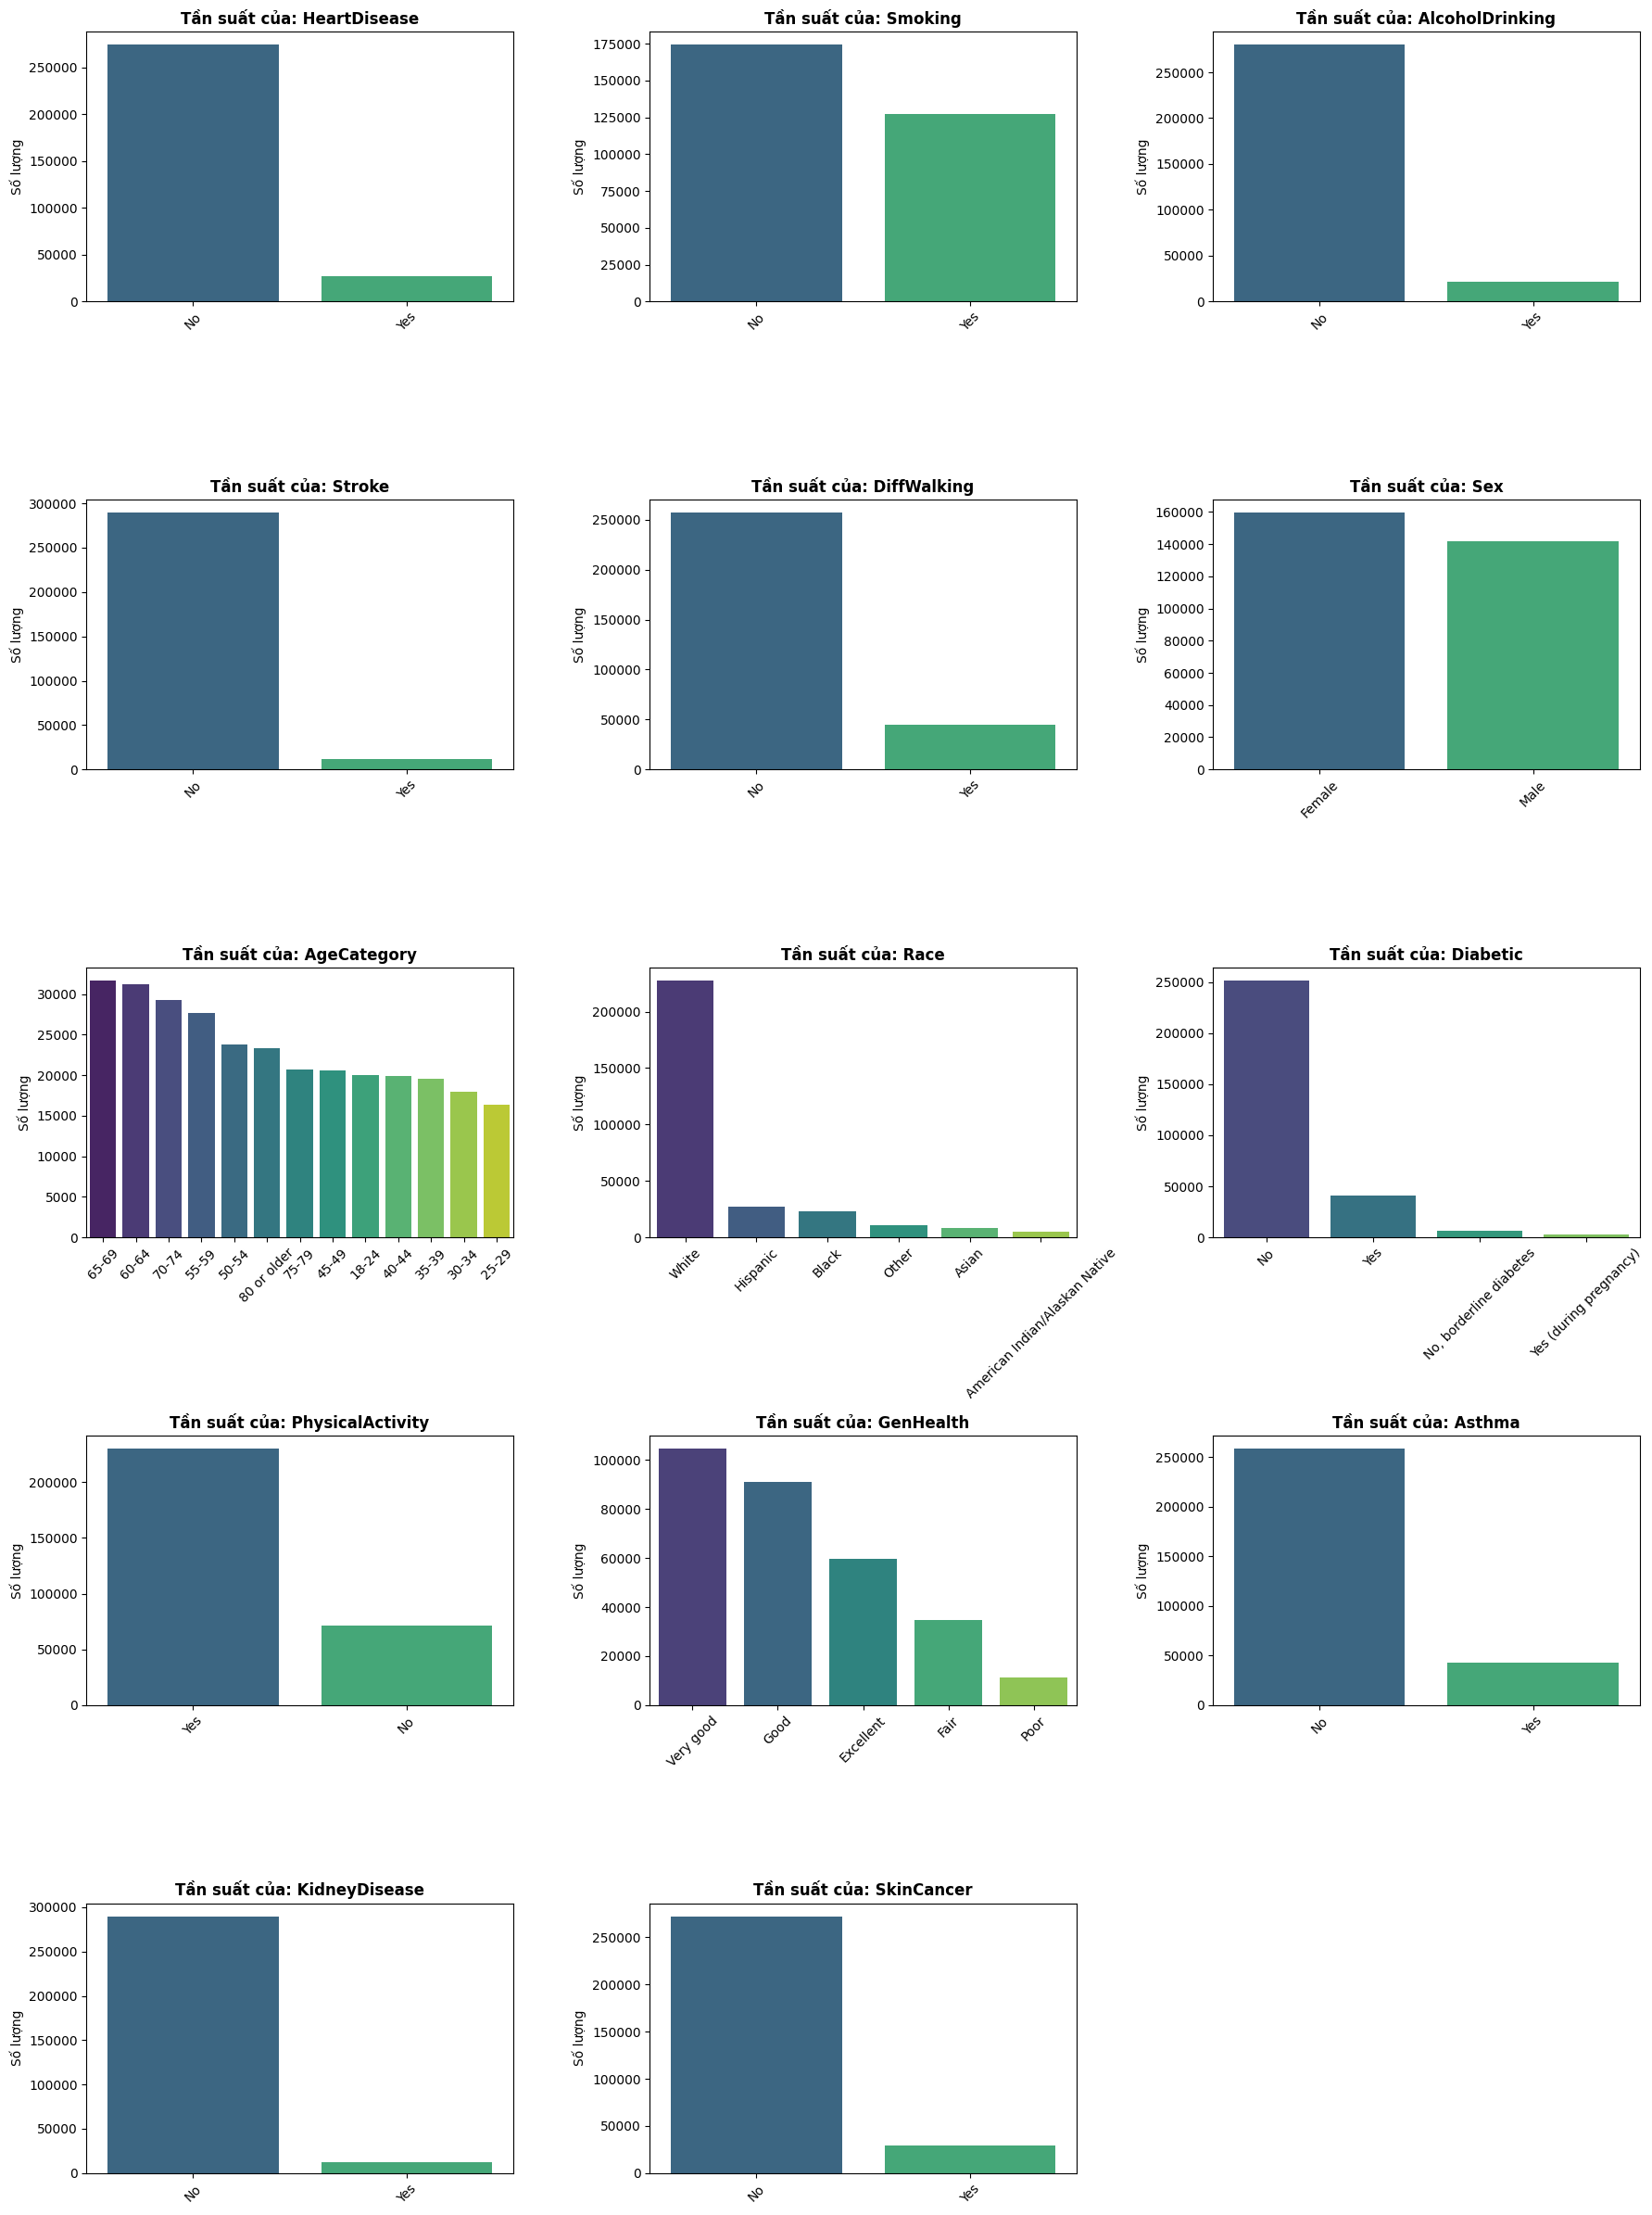

In [74]:
# Lấy danh sách các biến phân loại (loại trừ 4 biến số đã vẽ)
cat_cols = [col for col in df.columns if col not in num_cols]

# Tạo khung hình lớn chứa nhiều biểu đồ nhỏ (Grid)
plt.figure(figsize=(18, 24))

for i, col in enumerate(cat_cols):
    plt.subplot(5, 3, i+1) # Vẽ lưới 5 hàng 3 cột

    # Sắp xếp các cột theo số lượng từ cao xuống thấp để biểu đồ gọn gàng
    order = df[col].value_counts().index

    # Vẽ biểu đồ tần suất (Countplot) với màu sắc đồng bộ
    sns.countplot(data=df, x=col, order=order, palette='viridis')

    plt.title(f'Tần suất của: {col}', fontweight='bold')
    plt.xticks(rotation=45) # Xoay nghiêng chữ ở trục X để không bị đè lên nhau
    plt.xlabel('')
    plt.ylabel('Số lượng')

# Tự động căn chỉnh khoảng cách giữa các đồ thị
plt.tight_layout()
plt.show()

Kiểm tra phân bố nhãn HeartDisease

In [75]:
# Kiểm tra số lượng từng nhãn
label_count = df["HeartDisease"].value_counts()

# Kiểm tra tỷ lệ từng nhãn
label_ratio = df["HeartDisease"].value_counts(normalize=True)

print("Số lượng từng lớp:")
print(label_count)

print("Tỷ lệ từng lớp:")
print(label_ratio)

Số lượng từng lớp:
HeartDisease
No     274456
Yes     27261
Name: count, dtype: int64
Tỷ lệ từng lớp:
HeartDisease
No     0.909647
Yes    0.090353
Name: proportion, dtype: float64


Dữ liệu bị mất cân bằng nhãn khá rõ. Lớp No, tức không mắc bệnh tim, chiếm khoảng 91%. Lớp Yes, tức mắc bệnh tim, chỉ chiếm khoảng 9%.

Điều này có thể làm mô hình thiên về lớp chiếm đa số. Ví dụ, nếu mô hình luôn dự đoán mọi người là không mắc bệnh tim, mô hình vẫn có accuracy khoảng 91%, nhưng thực tế mô hình đó gần như vô dụng vì không phát hiện được người mắc bệnh tim.

Ví vậy khi đánh giá cần quan tâm thêm các chỉ số như :  
Precision  
Recall  
F1-score  
Confusion matrix  

Chuyển đổi dữ liệu về dạng phù hợp

Mã hóa các biến Yes/No

Các cột dạng Yes/No gồm :  
HeartDisease  
Smoking  
AlcoholDrinking  
Stroke  
DiffWalking  
PhysicalActivity  
Asthma  
KidneyDisease  
SkinCancer  

In [76]:
binary_cols = [
    "HeartDisease",
    "Smoking",
    "AlcoholDrinking",
    "Stroke",
    "DiffWalking",
    "PhysicalActivity",
    "Asthma",
    "KidneyDisease",
    "SkinCancer"
]

for col in binary_cols:
    df[col] = df[col].map({
        "No": 0,
        "Yes": 1
    })

In [77]:
# Xóa khoảng trắng thừa và chuẩn hóa chuỗi trước khi mã hóa
df['Sex'] = df['Sex'].str.strip().map({
    "Female": 0,
    "Male": 1
})

# Kiểm tra lại xem còn giá trị NaN không
print("Số giá trị NaN trong cột Sex:", df['Sex'].isnull().sum())

Số giá trị NaN trong cột Sex: 0


Mã hóa biến AgeCategory

In [78]:
age_order = [
    "18-24", "25-29", "30-34", "35-39", "40-44",
    "45-49", "50-54", "55-59", "60-64", "65-69",
    "70-74", "75-79", "80 or older"
]

age_map = {age: idx for idx, age in enumerate(age_order)}

df["AgeCategory"] = df["AgeCategory"].map(age_map)

Mã hóa biến GenHealth

In [79]:
gen_health_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Very good": 4,
    "Excellent": 5
}

df["GenHealth"] = df["GenHealth"].map(gen_health_map)

One-hot encoding cho Race và Diabetic

In [80]:
df = pd.get_dummies(
    df,
    columns=["Race", "Diabetic"],
    drop_first=False,
    dtype=int
)

Đưa HeartDisease về cột đầu tiên

In [81]:
target = df.pop("HeartDisease")
df.insert(0, "HeartDisease", target)

print("Kích thước dữ liệu sau mã hóa:", df.shape)
display(df.head(15))

Kích thước dữ liệu sau mã hóa: (301717, 26)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,0,16.60,1,0,0,3.0,30.0,0,0,7,...,0,0,0,0,0,1,0,0,1,0
1,0,20.34,0,0,1,0.0,0.0,0,0,12,...,0,0,0,0,0,1,1,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,...,0,0,0,0,0,1,0,0,1,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,...,0,0,0,0,0,1,1,0,0,0
4,0,23.71,0,0,0,28.0,0.0,1,0,4,...,0,0,0,0,0,1,1,0,0,0
5,1,28.87,1,0,0,6.0,0.0,1,0,11,...,0,0,1,0,0,0,1,0,0,0
6,0,21.63,0,0,0,15.0,0.0,0,0,10,...,0,0,0,0,0,1,1,0,0,0
7,0,31.64,1,0,0,5.0,0.0,1,0,12,...,0,0,0,0,0,1,0,0,1,0
8,0,26.45,0,0,0,0.0,0.0,0,0,12,...,0,0,0,0,0,1,0,1,0,0
9,0,40.69,0,0,0,0.0,0.0,1,1,9,...,0,0,0,0,0,1,1,0,0,0


## Biểu đồ tương quan(Heatmap)

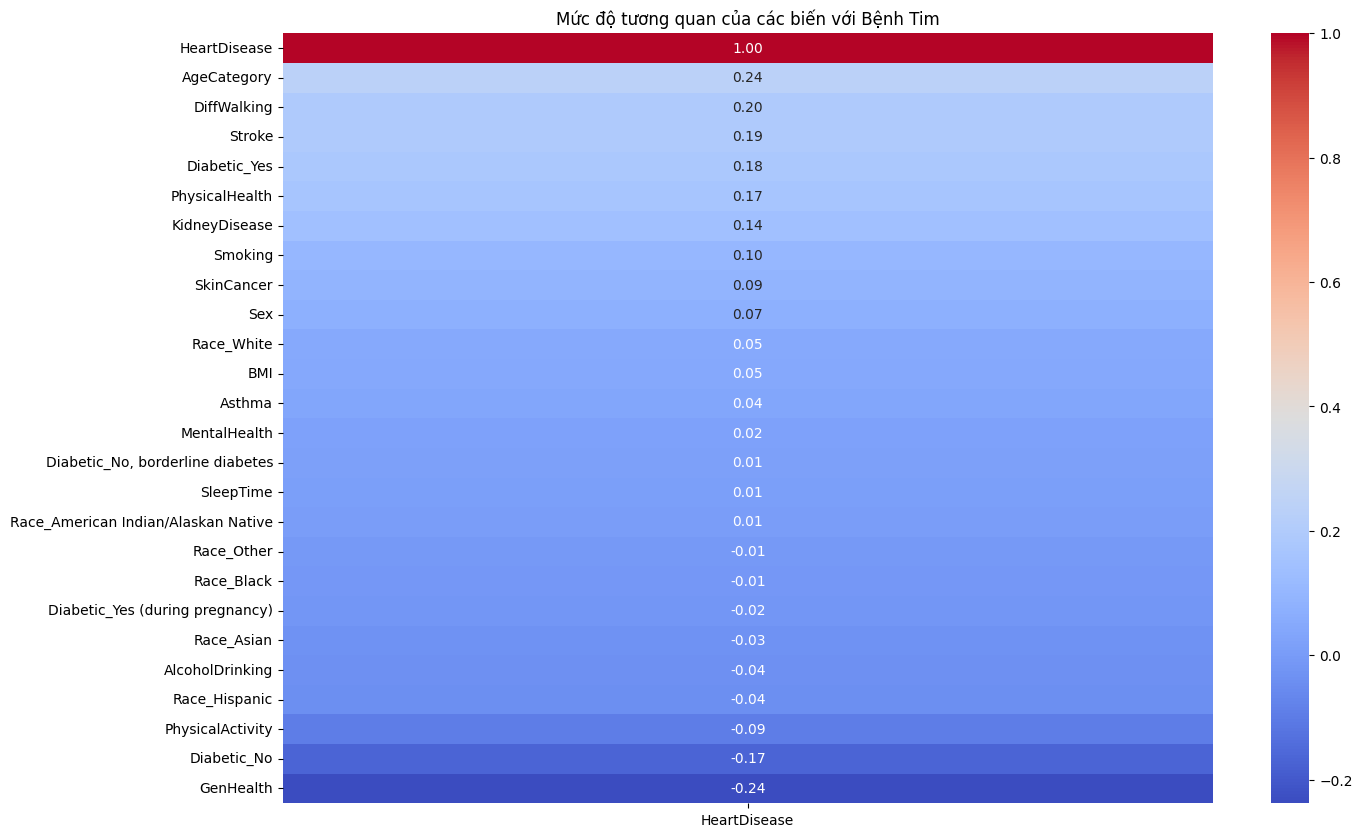

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán ma trận tương quan
# Nếu không có `df_cleaned`, dùng `df` sau tiền xử lý
corr_matrix = df.corr()

# Vẽ Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix[['HeartDisease']].sort_values(by='HeartDisease', ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mức độ tương quan của các biến với Bệnh Tim')
plt.show()

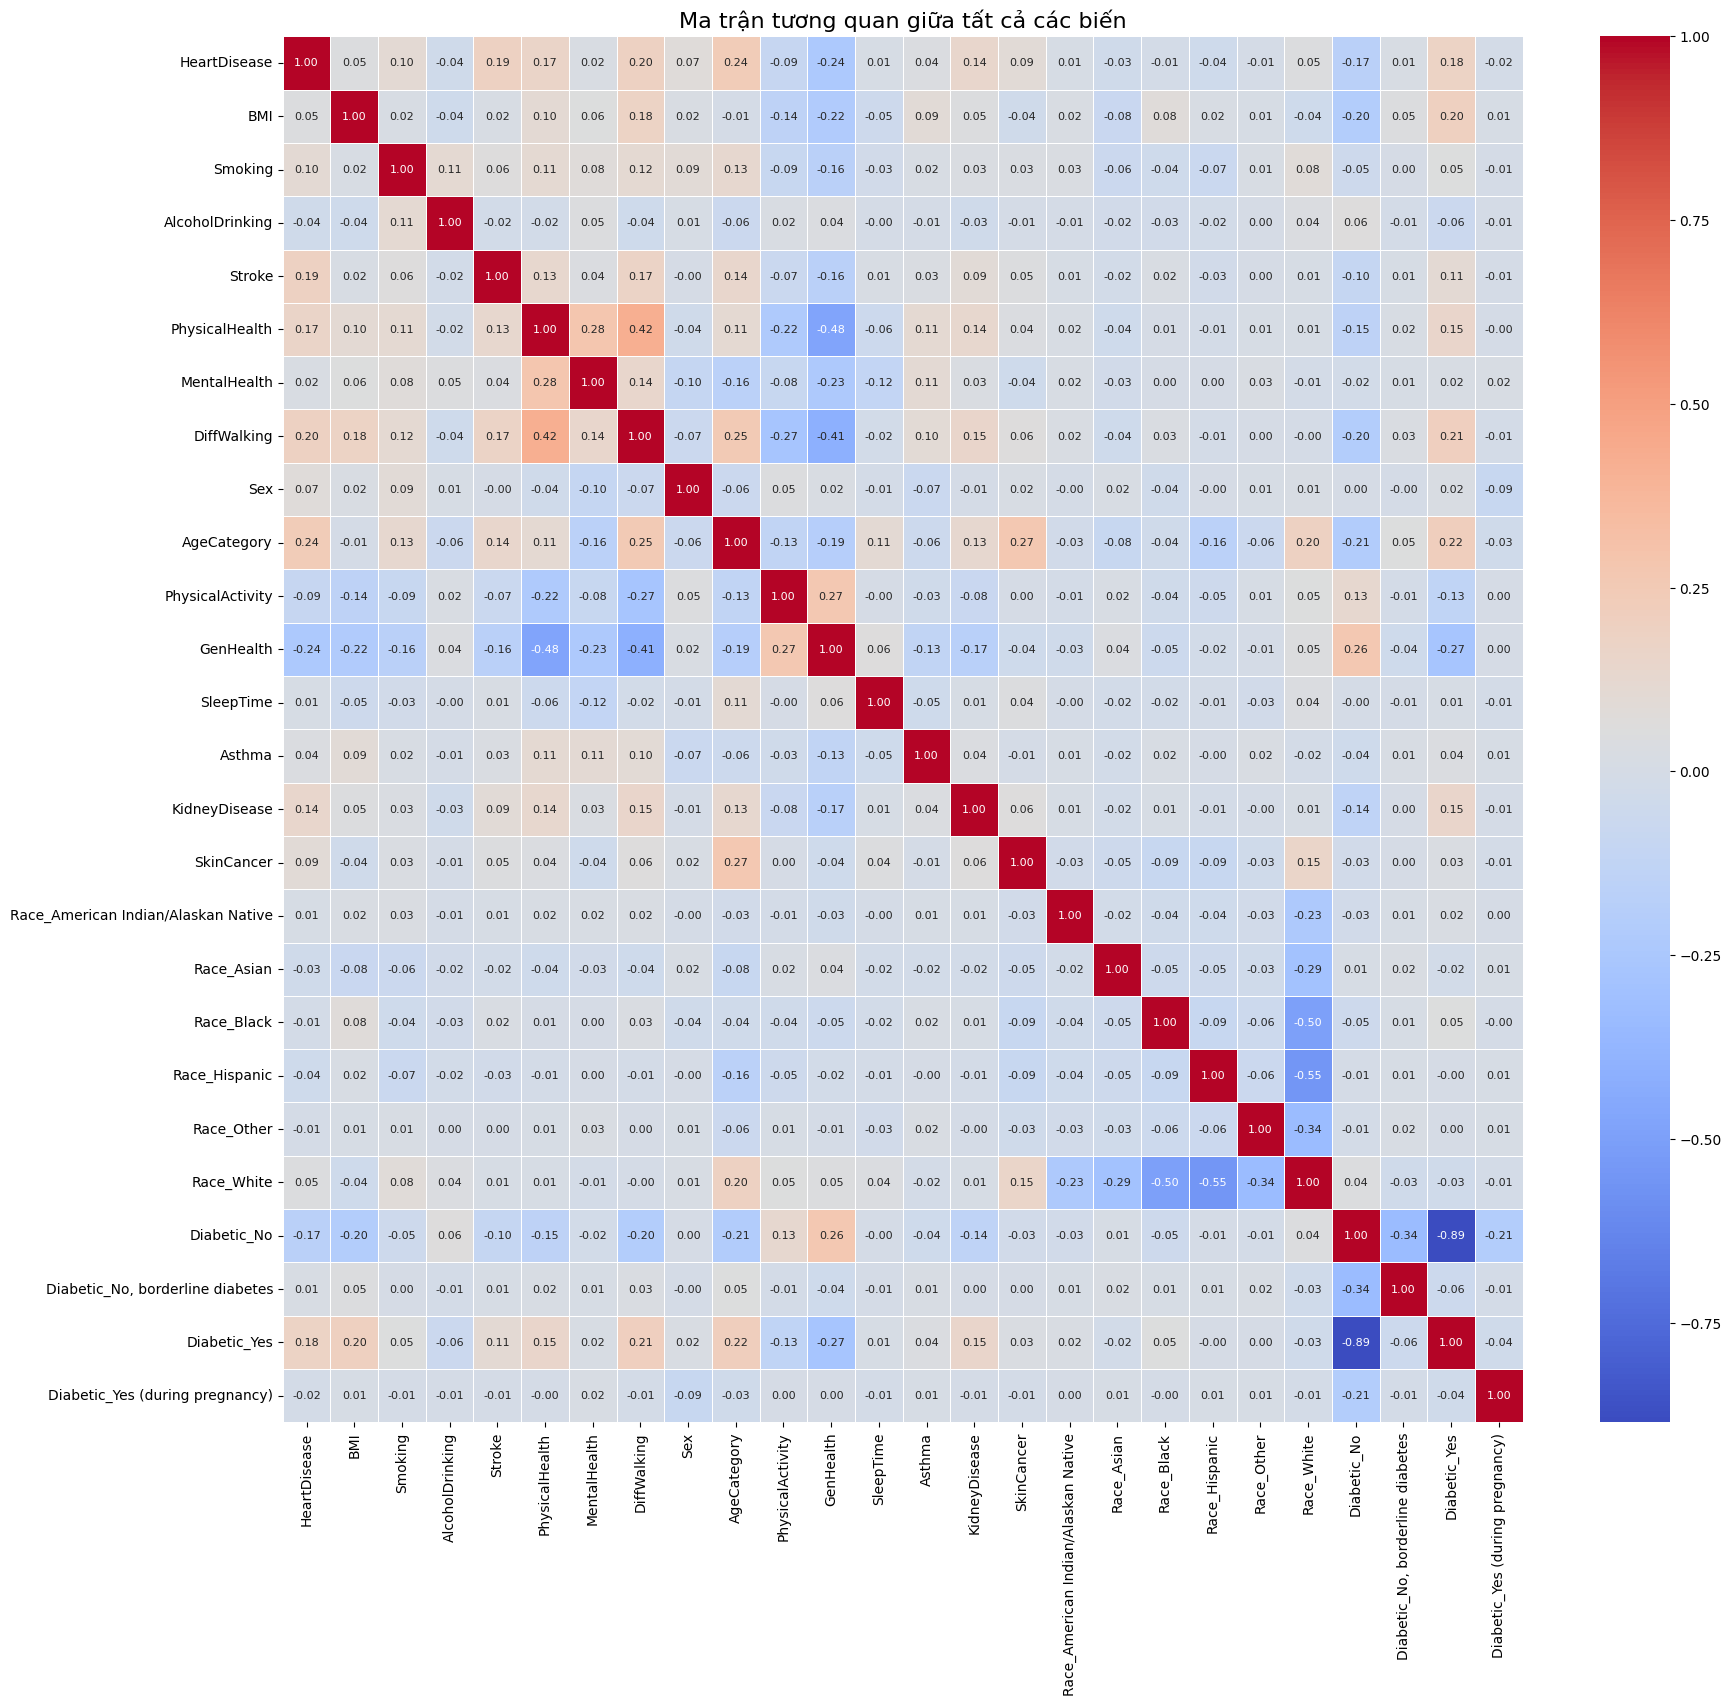

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán ma trận tương quan đầy đủ
full_corr_matrix = df.corr()

# Vẽ Heatmap cho toàn bộ ma trận tương quan
plt.figure(figsize=(20, 18)) # Kích thước lớn hơn để hiển thị nhiều biến
sns.heatmap(full_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
plt.title('Ma trận tương quan giữa tất cả các biến', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## Chia dữ liệu train/test

In [84]:
from sklearn.model_selection import train_test_split

# 1. Tách biến độc lập (X) và biến mục tiêu (y)
# Dùng df sau khi đã xử lý và mã hóa để tránh còn giá trị chuỗi
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

print(f"Tổng số bản ghi ban đầu: {len(df)}\n")
print("-" * 50)

# ==========================================
# TRƯỜNG HỢP 1: TỈ LỆ 4:1 (80% Train - 20% Test)
# Đây là tỉ lệ "Vàng" phổ biến nhất.
# ==========================================
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("1. KẾT QUẢ CHIA TỈ LỆ 4:1 (80/20)")
print(f"   - Tập Train (80%): {X_train_80.shape[0]} dòng")
print(f"   - Tập Test  (20%): {X_test_20.shape[0]} dòng")
print("-" * 50)


# ==========================================
# TRƯỜNG HỢP 2: TỈ LỆ 7:3 (70% Train - 30% Test)
# Dùng khi bộ dữ liệu cực lớn, cần tập Test lớn hơn để đánh giá chắc chắn.
# ==========================================
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("2. KẾT QUẢ CHIA TỈ LỆ 7:3 (70/30)")
print(f"   - Tập Train (70%): {X_train_70.shape[0]} dòng")
print(f"   - Tập Test  (30%): {X_test_30.shape[0]} dòng")
print("-" * 50)


# ==========================================
# TRƯỜNG HỢP 3: TỈ LỆ 6:4 (60% Train - 40% Test)
# Dùng để kiểm tra xem mô hình có bị Overfitting nặng không khi thiếu dữ liệu học.
# ==========================================
X_train_60, X_test_40, y_train_60, y_test_40 = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
print("3. KẾT QUẢ CHIA TỈ LỆ 6:4 (60/40)")
print(f"   - Tập Train (60%): {X_train_60.shape[0]} dòng")
print(f"   - Tập Test  (40%): {X_test_40.shape[0]} dòng")
print("-" * 50)

Tổng số bản ghi ban đầu: 301717

--------------------------------------------------
1. KẾT QUẢ CHIA TỈ LỆ 4:1 (80/20)
   - Tập Train (80%): 241373 dòng
   - Tập Test  (20%): 60344 dòng
--------------------------------------------------
2. KẾT QUẢ CHIA TỈ LỆ 7:3 (70/30)
   - Tập Train (70%): 211201 dòng
   - Tập Test  (30%): 90516 dòng
--------------------------------------------------
3. KẾT QUẢ CHIA TỈ LỆ 6:4 (60/40)
   - Tập Train (60%): 181030 dòng
   - Tập Test  (40%): 120687 dòng
--------------------------------------------------


tham số stratify=y đảm bảo người mắc bệnh có tỉ lệ đồng đều ở cả 2 tập


## Chuẩn hóa các dữ liệu dạng số

In [85]:
from sklearn.preprocessing import StandardScaler

def scale_data(X_train, X_test):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)  # fit + transform train
    X_test_scaled = scaler.transform(X_test)        # chỉ transform test

    return X_train_scaled, X_test_scaled, scaler

# 80/20
X_train_80_s, X_test_20_s, scaler_80 = scale_data(X_train_80, X_test_20)

# 70/30
X_train_70_s, X_test_30_s, scaler_70 = scale_data(X_train_70, X_test_30)

# 60/40
X_train_60_s, X_test_40_s, scaler_60 = scale_data(X_train_60, X_test_40)

In [86]:
import numpy as np

def check_scaling(X_train_s, X_test_s, name):
    print(f"\n=== {name} ===")
    print("Train mean (≈0):", np.mean(X_train_s, axis=0)[:5])
    print("Train std  (≈1):", np.std(X_train_s, axis=0)[:5])

    print("Test mean  :", np.mean(X_test_s, axis=0)[:5])
    print("Test std   :", np.std(X_test_s, axis=0)[:5])

# Kiểm tra 3 bộ
check_scaling(X_train_80_s, X_test_20_s, "80/20")
check_scaling(X_train_70_s, X_test_30_s, "70/30")
check_scaling(X_train_60_s, X_test_40_s, "60/40")


=== 80/20 ===
Train mean (≈0): [-1.12710453e-15  1.95759641e-17 -4.33909341e-17 -6.11123332e-17
  5.38118232e-17]
Train std  (≈1): [1. 1. 1. 1. 1.]
Test mean  : [ 0.00112477  0.00997405  0.00287696 -0.00451812 -0.00539367]
Test std   : [1.00117422 1.00153919 1.0047741  0.98935136 0.99033838]

=== 70/30 ===
Train mean (≈0): [-7.18142681e-16  5.77313239e-17 -7.56966660e-18  3.97996248e-17
 -3.05478101e-17]
Train std  (≈1): [1. 1. 1. 1. 1.]
Test mean  : [ 0.00274367  0.01020203  0.0078475   0.00410114 -0.00634592]
Test std   : [0.99458543 1.00158431 1.01300206 1.00960759 0.98990052]

=== 60/40 ===
Train mean (≈0): [ 1.02849717e-15 -1.01382748e-16 -4.74139990e-17  4.65406866e-17
 -1.06759998e-17]
Train std  (≈1): [1. 1. 1. 1. 1.]
Test mean  : [ 0.00236958  0.00777426  0.0050319   0.00977361 -0.00268563]
Test std   : [0.99950569 1.00121734 1.00835694 1.02288818 0.99559918]


### Trực quan hóa mức độ đóng góp của các thành phần chính (PCA)
Biểu đồ dưới đây thể hiện tỷ lệ phương sai được giải thích bởi mỗi thành phần và tổng tích lũy của chúng để đạt ngưỡng 95% thông tin.

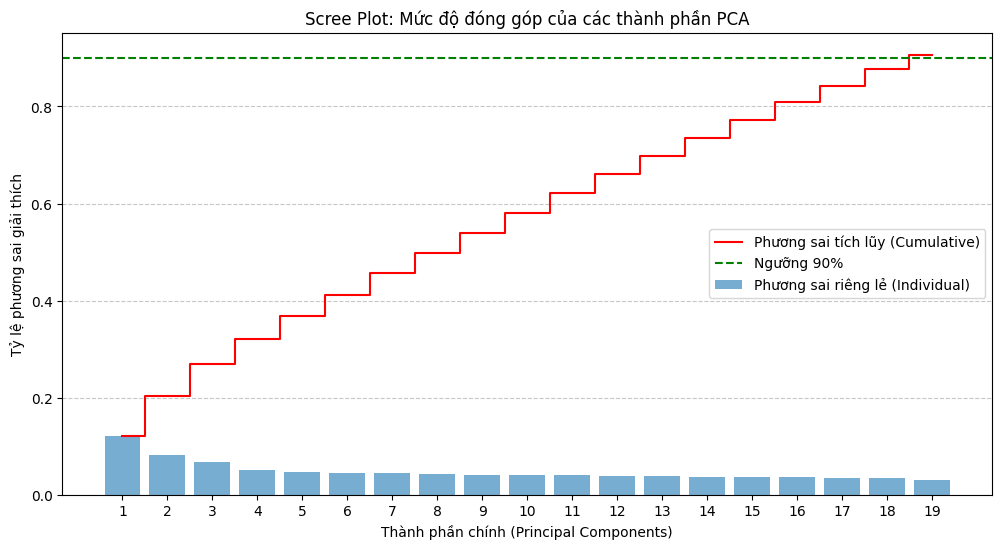

Tổng số thành phần cần thiết để giữ 90% phương sai: 19


,Thành phần chính,Phương sai riêng lẻ,Phương sai tích lũy
0,PC1,12.12%,12.12%
1,PC2,8.12%,20.24%
2,PC3,6.66%,26.90%
3,PC4,5.13%,32.03%
4,PC5,4.70%,36.73%
5,PC6,4.46%,41.19%
6,PC7,4.41%,45.60%
7,PC8,4.26%,49.85%
8,PC9,4.15%,54.00%
9,PC10,4.14%,58.14%


In [107]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# Khởi tạo PCA để giữ lại 95% phương sai dựa trên tập train 80/20
pca = PCA(n_components=0.90)
pca.fit(X_train_80_s)

# Lấy dữ liệu phương sai
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.6, align='center', label='Phương sai riêng lẻ (Individual)')
plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid', color='red', label='Phương sai tích lũy (Cumulative)')

plt.axhline(y=0.90, color='green', linestyle='--', label='Ngưỡng 90%')
plt.ylabel('Tỷ lệ phương sai giải thích')
plt.xlabel('Thành phần chính (Principal Components)')
plt.title('Scree Plot: Mức độ đóng góp của các thành phần PCA')
plt.xticks(np.arange(1, len(exp_var_pca) + 1, 1))
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Thêm bảng chứa lượng thông tin giữ lại
pca_summary_table = pd.DataFrame({
    'Thành phần chính': [f'PC{i+1}' for i in range(len(exp_var_pca))],
    'Phương sai riêng lẻ': [f'{v:.2%}' for v in exp_var_pca],
    'Phương sai tích lũy': [f'{c:.2%}' for c in cum_sum_eigenvalues]
})

print(f"Tổng số thành phần cần thiết để giữ 90% phương sai: {len(exp_var_pca)}")
display(pca_summary_table)

### 1. Phân tích tham số thống kê của dữ liệu
Trước khi giảm chiều, chúng ta cần xem xét các đặc tính thống kê cơ bản của dữ liệu đã chuẩn hóa.

In [88]:
import pandas as pd
import numpy as np

# Chuyển đổi mảng đã chuẩn hóa về DataFrame để dễ phân tích
X_train_df = pd.DataFrame(X_train_80_s, columns=X.columns)

# Thống kê mô tả (Mean, Std, Min, Max)
stats_summary = X_train_df.describe().T
display(stats_summary[['mean', 'std', 'min', 'max']].head(10))

,mean,std,min,max
BMI,-1.127105e-15,1.000002,-2.530001,10.269608
Smoking,1.957596e-17,1.000002,-0.853203,1.172053
AlcoholDrinking,-4.339093e-17,1.000002,-0.277247,3.606895
Stroke,-6.111233e-17,1.000002,-0.204554,4.888682
PhysicalHealth,5.381182e-17,1.000002,-0.439058,3.239070
MentalHealth,-2.440372e-17,1.000002,-0.506526,3.180313
DiffWalking,-9.358194e-17,1.000002,-0.415844,2.404747
Sex,-1.839846e-17,1.000002,-0.944501,1.058760
AgeCategory,-1.002643e-16,1.000002,-1.816830,1.532528
PhysicalActivity,5.852183e-17,1.000002,-1.799826,0.555609


### 2. Thực hiện PCA và Đánh giá phương sai giải thích
Chúng ta sẽ xác định lượng thông tin được bảo toàn qua các thành phần chính.

In [89]:
from sklearn.decomposition import PCA

# Khởi tạo PCA giữ lại toàn bộ các thành phần để đánh giá
pca_full = PCA()
pca_full.fit(X_train_80_s)

# Tỷ lệ phương sai giải thích
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Hiển thị bảng thông số cho 6 thành phần đầu tiên
pca_stats = pd.DataFrame({
    'Thành phần chính': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Phương sai riêng lẻ': explained_variance,
    'Phương sai tích lũy': cumulative_variance
})
display(pca_stats.head(6))

,Thành phần chính,Phương sai riêng lẻ,Phương sai tích lũy
0,PC1,0.121234,0.121234
1,PC2,0.081200,0.202434
2,PC3,0.066551,0.268985
3,PC4,0.051323,0.320308
4,PC5,0.046971,0.367279
5,PC6,0.044596,0.411875


### 3. Trực quan hóa các cặp thành phần chính (PC1 đến PC6)
Sử dụng các biểu đồ Scatter Plot để quan sát sự phân bố dữ liệu.

/tmp/ipykernel_7210/3188176915.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


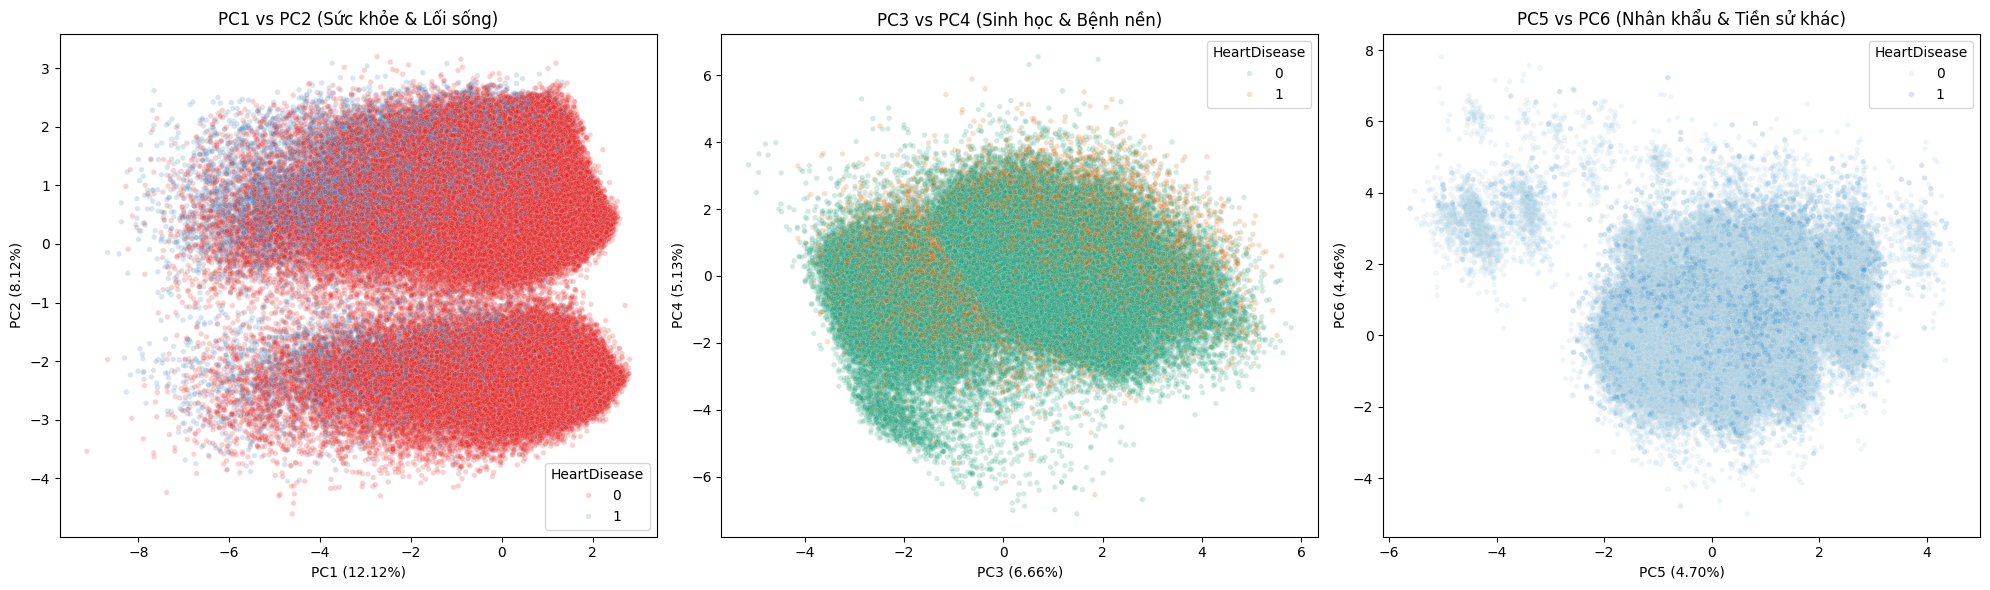

In [105]:
# Trực quan hóa lại các cặp thành phần chính từ PC1 đến PC6 với màu sắc rõ ràng hơn
import matplotlib.pyplot as plt
import seaborn as sns

# Đảm bảo X_pca đã được transform từ pca_full
X_pca_plot = pca_full.transform(X_train_80_s)

plt.figure(figsize=(20, 6))

# Cặp PC1 - PC2: Sức khỏe tổng quát, Vận động vs Lối sống
plt.subplot(1, 3, 1)
sns.scatterplot(x=X_pca_plot[:, 0], y=X_pca_plot[:, 1], hue=y_train_80, alpha=0.2, palette='Set1', s=15)
plt.title('PC1 vs PC2 (Sức khỏe & Lối sống)')
plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%})')

# Cặp PC3 - PC4: Chỉ số sinh học & Bệnh nền (BMI, Tiểu đường...)
plt.subplot(1, 3, 2)
sns.scatterplot(x=X_pca_plot[:, 2], y=X_pca_plot[:, 3], hue=y_train_80, alpha=0.2, palette='Dark2', s=15)
plt.title('PC3 vs PC4 (Sinh học & Bệnh nền)')
plt.xlabel(f'PC3 ({pca_full.explained_variance_ratio_[2]:.2%})')
plt.ylabel(f'PC4 ({pca_full.explained_variance_ratio_[3]:.2%})')

# Cặp PC5 - PC6: Nhân khẩu học & Tiền sử bệnh khác
plt.subplot(1, 3, 3)
sns.scatterplot(x=X_pca_plot[:, 4], y=X_pca_plot[:, 5], hue=y_train_80, alpha=0.2, palette='Paired', s=15)
plt.title('PC5 vs PC6 (Nhân khẩu & Tiền sử khác)')
plt.xlabel(f'PC5 ({pca_full.explained_variance_ratio_[4]:.2%})')
plt.ylabel(f'PC6 ({pca_full.explained_variance_ratio_[5]:.2%})')

plt.tight_layout()
plt.show()

### Bảng thống kê toàn bộ phương sai giải thích (Toàn bộ 25 thành phần)
Dưới đây là bảng chi tiết cho tất cả các thành phần chính để đánh giá mức độ đóng góp của từng chiều dữ liệu.

In [108]:
# Khởi tạo PCA cho toàn bộ số chiều (25)
pca_all = PCA(n_components=X_train_80_s.shape[1])
pca_all.fit(X_train_80_s)

# Lấy dữ liệu phương sai
exp_var_all = pca_all.explained_variance_ratio_
cum_sum_all = np.cumsum(exp_var_all)

# Tạo bảng tổng hợp
full_pca_summary = pd.DataFrame({
    'Thành phần chính': [f'PC{i+1}' for i in range(len(exp_var_all))],
    'Phương sai riêng lẻ': [f'{v:.4%}' for v in exp_var_all],
    'Phương sai tích lũy': [f'{c:.4%}' for c in cum_sum_all]
})

display(full_pca_summary)

,Thành phần chính,Phương sai riêng lẻ,Phương sai tích lũy
0,PC1,12.1234%,12.1234%
1,PC2,8.1200%,20.2434%
2,PC3,6.6551%,26.8985%
3,PC4,5.1323%,32.0308%
4,PC5,4.6971%,36.7279%
5,PC6,4.4596%,41.1875%
6,PC7,4.4116%,45.5992%
7,PC8,4.2556%,49.8548%
8,PC9,4.1492%,54.0040%
9,PC10,4.1406%,58.1446%


### Giải thích ý nghĩa các thành phần chính (PC1 - PC6)
Trong PCA, các thành phần chính (PC) là sự kết hợp tuyến tính của các đặc trưng gốc. Dưới đây là ý nghĩa sơ bộ:

*   **PC1 (Sức khỏe tổng quát & Vận động):** Thường liên quan mạnh đến các biến như `GenHealth`, `DiffWalking`, `PhysicalHealth` và `AgeCategory`. Nó đại diện cho tình trạng suy giảm thể chất chung.
*   **PC2 (Lối sống & Thói quen):** Thường phản ánh các yếu tố như `Smoking`, `AlcoholDrinking` và `PhysicalActivity`.
*   **PC3 & PC4 (Chỉ số sinh học & Bệnh nền):** Thường tập trung vào `BMI`, `SleepTime` và tình trạng `Diabetic` hoặc `Asthma`.
*   **PC5 & PC6 (Đặc điểm nhân khẩu học & Tiền sử khác):** Thường liên quan đến `Sex`, `Race` hoặc các bệnh ít phổ biến hơn như `KidneyDisease` và `SkinCancer`.

**Lưu ý:** Vì các điểm dữ liệu chồng lấn, điều này cho thấy không có một thành phần đơn lẻ nào (ví dụ: chỉ mình PC1) đủ mạnh để tách biệt hoàn toàn người bệnh và người khỏe mạnh. Cần sự kết hợp của nhiều PC để mô hình dự đoán chính xác hơn.

### 4. Phân tích tương quan giữa các thành phần chính và đầu ra
Biểu đồ Boxplot giúp nhận diện liệu các thành phần chính có khả năng phân tách được người mắc bệnh tim hay không.

/tmp/ipykernel_7210/37098332.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y=f'PC{i+1}', data=pca_df, palette='Set2')
/tmp/ipykernel_7210/37098332.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y=f'PC{i+1}', data=pca_df, palette='Set2')
/tmp/ipykernel_7210/37098332.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y=f'PC{i+1}', data=pca_df, palette='Set2')
/tmp/ipykernel_7210/37098332.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

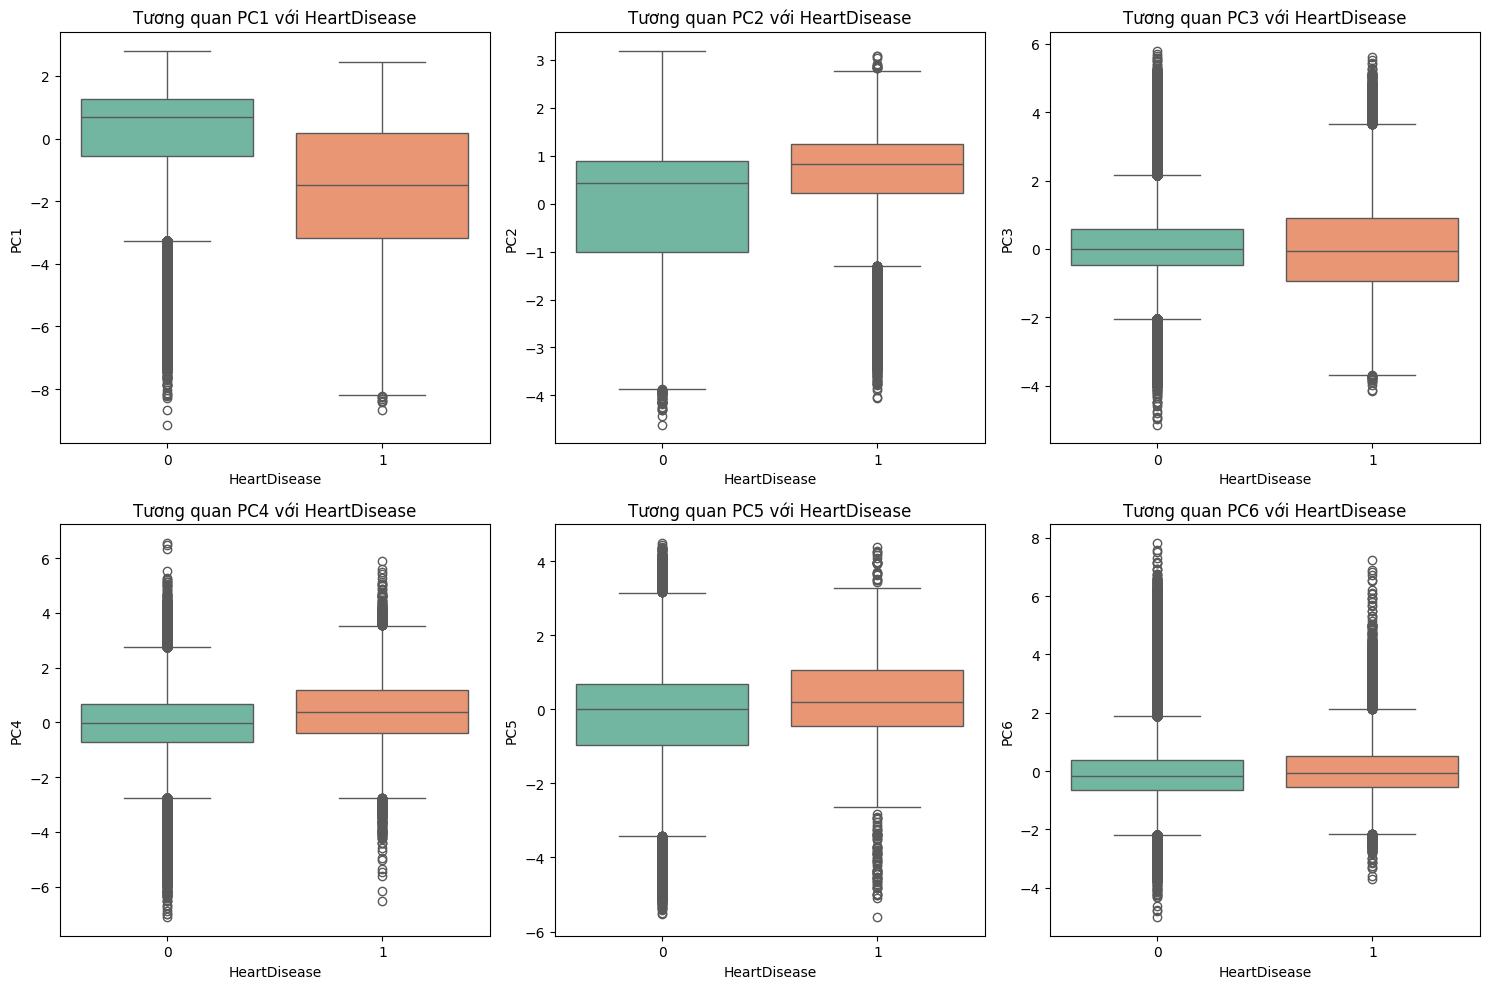

In [91]:
# Tạo DataFrame kết hợp giữa PCA và nhãn
pca_df = pd.DataFrame(X_pca[:, :6], columns=[f'PC{i+1}' for i in range(6)])
pca_df['HeartDisease'] = y_train_80.values

plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='HeartDisease', y=f'PC{i+1}', data=pca_df, palette='Set2')
    plt.title(f'Tương quan PC{i+1} với HeartDisease')

plt.tight_layout()
plt.show()

### 5. So sánh và Đánh giá tổng thể
- **Thông tin bảo tồn:** Thành phần chính PC1 giải thích khoảng 12% phương sai, và cần tới 19 thành phần để giữ lại 90% thông tin. Điều này cho thấy dữ liệu có độ phức tạp cao và các biến có sự đóng góp khá đồng đều.
- **Cụm dữ liệu:** Qua biểu đồ Scatter Plot, các lớp (Bệnh tim/Không bệnh tim) chồng lấn lên nhau rất nhiều trong không gian PCA, cho thấy bài toán phân loại này không tuyến tính và khá thách thức.
- **Giảm chiều:** PCA giúp giảm từ 25 chiều xuống không gian ít hơn nhưng vẫn giữ được cấu trúc dữ liệu chính, hỗ trợ mô hình huấn luyện nhanh hơn.

### Phân tích chi tiết PCA với k = 2
Trong phần này, chúng ta tập trung giảm chiều dữ liệu xuống còn 2 thành phần chính (k=2) để trực quan hóa và đánh giá khả năng phân tách của hai lớp đối tượng (Bệnh tim / Không bệnh tim).

### Xác định lượng thông tin bảo tồn (Explained Variance)
Chúng ta sẽ so sánh tổng phương sai tích lũy của 19 thành phần chính đầu tiên trên cả 3 bộ dữ liệu (80/20, 70/30, 60/40) để xem mức độ ổn định của việc giữ lại thông tin.

In [106]:
import pandas as pd
from sklearn.decomposition import PCA

def get_explained_variance(X_train, n_comp=19):
    pca = PCA(n_components=n_comp)
    pca.fit(X_train)
    return sum(pca.explained_variance_ratio_)

# Tính toán cho 3 kịch bản
var_80 = get_explained_variance(X_train_80_s)
var_70 = get_explained_variance(X_train_70_s)
var_60 = get_explained_variance(X_train_60_s)

# Hiển thị kết quả
variance_summary = pd.DataFrame({
    'Kịch bản (Split Ratio)': ['80/20', '70/30', '60/40'],
    'Số lượng PC': [19, 19, 19],
    'Tổng phương sai giải thích': [f"{var_80:.2%}", f"{var_70:.2%}", f"{var_60:.2%}"]
})

display(variance_summary)

,Kịch bản (Split Ratio),Số lượng PC,Tổng phương sai giải thích
0,80/20,19,90.66%
1,70/30,19,90.66%
2,60/40,19,90.65%


##  Hồi quy Logistic trên tất cả các tập dữ liệu
 thực hiện huấn luyện mô hình Logistic Regression (Binary) cho từng tỉ lệ phân chia đã thực hiện ở bước trước.

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_logistic(X_train, y_train, X_test, y_test, label):
    # Sử dụng Logistic Regression mặc định (Binary)
    # model = LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0)
    # model.fit(X_train, y_train)
    model = LogisticRegression(class_weight = 'balanced', max_iter = 1000, solver = 'lbfgs')
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"--- {label} ---")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Độ chênh lệch (Gap): {abs(train_acc - test_acc):.4f}")
    print("Báo cáo phân loại:")
    print(classification_report(y_test, y_test_pred))
    print("="*50)
    return train_acc, test_acc

# 1. Thực hiện với dữ liệu GỐC (Original Scaled)
print("PHẦN 1: DỮ LIỆU GỐC ĐÃ CHUẨN HÓA\n")
results_orig = {}
results_orig['80/20'] = evaluate_logistic(X_train_80_s, y_train_80, X_test_20_s, y_test_20, "Tỉ lệ 80/20 - Gốc")
results_orig['70/30'] = evaluate_logistic(X_train_70_s, y_train_70, X_test_30_s, y_test_30, "Tỉ lệ 70/30 - Gốc")
results_orig['60/40'] = evaluate_logistic(X_train_60_s, y_train_60, X_test_40_s, y_test_40, "Tỉ lệ 60/40 - Gốc")

PHẦN 1: DỮ LIỆU GỐC ĐÃ CHUẨN HÓA

--- Tỉ lệ 80/20 - Gốc ---
Train Accuracy: 0.7442
Test Accuracy:  0.7429
Độ chênh lệch (Gap): 0.0013
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     54892
           1       0.23      0.77      0.35      5452

    accuracy                           0.74     60344
   macro avg       0.60      0.76      0.60     60344
weighted avg       0.90      0.74      0.80     60344

--- Tỉ lệ 70/30 - Gốc ---
Train Accuracy: 0.7448
Test Accuracy:  0.7427
Độ chênh lệch (Gap): 0.0021
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     82338
           1       0.23      0.77      0.35      8178

    accuracy                           0.74     90516
   macro avg       0.60      0.75      0.60     90516
weighted avg       0.90      0.74      0.80     90516

--- Tỉ lệ 60/40 - Gốc ---
Train Accuracy: 0.7462
Test Accuracy:  0.7428
Độ

In [93]:
# 2. Thực hiện với dữ liệu GIẢM CHIỀU (PCA)
# Trước hết, tạo các tập dữ liệu PCA tương ứng cho từng tỉ lệ
print("\nPHẦN 2: DỮ LIỆU ĐÃ GIẢM CHIỀU (PCA)\n")

# PCA cho 80/20 (đã fit ở cell trước)
X_train_80_pca = pca.transform(X_train_80_s)
X_test_20_pca = pca.transform(X_test_20_s)

# PCA cho 70/30
pca_70 = PCA(n_components=19).fit(X_train_70_s)
X_train_70_pca = pca_70.transform(X_train_70_s)
X_test_30_pca = pca_70.transform(X_test_30_s)

# PCA cho 60/40
pca_60 = PCA(n_components=19).fit(X_train_60_s)
X_train_60_pca = pca_60.transform(X_train_60_s)
X_test_40_pca = pca_60.transform(X_test_40_s)

evaluate_logistic(X_train_80_pca, y_train_80, X_test_20_pca, y_test_20, "Tỉ lệ 80/20 - PCA")
evaluate_logistic(X_train_70_pca, y_train_70, X_test_30_pca, y_test_30, "Tỉ lệ 70/30 - PCA")
evaluate_logistic(X_train_60_pca, y_train_60, X_test_40_pca, y_test_40, "Tỉ lệ 60/40 - PCA")


PHẦN 2: DỮ LIỆU ĐÃ GIẢM CHIỀU (PCA)

--- Tỉ lệ 80/20 - PCA ---
Train Accuracy: 0.7581
Test Accuracy:  0.7567
Độ chênh lệch (Gap): 0.0014
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     54892
           1       0.23      0.71      0.34      5452

    accuracy                           0.76     60344
   macro avg       0.60      0.73      0.60     60344
weighted avg       0.90      0.76      0.80     60344

--- Tỉ lệ 70/30 - PCA ---
Train Accuracy: 0.7589
Test Accuracy:  0.7564
Độ chênh lệch (Gap): 0.0025
Báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     82338
           1       0.23      0.70      0.34      8178

    accuracy                           0.76     90516
   macro avg       0.59      0.73      0.60     90516
weighted avg       0.90      0.76      0.80     90516

--- Tỉ lệ 60/40 - PCA ---
Train Accuracy: 0.7590
Test Accuracy:  0.755

(0.7590399381318014, 0.7551848997820809)

In [97]:
def train_with_regularization(X_train, y_train, X_test, y_test, C_val, label):
    model = LogisticRegression(class_weight = 'balanced', max_iter = 1000, solver = 'lbfgs')
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"[{label}] C={C_val} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Gap: {abs(train_acc-test_acc):.4f}")
    return train_acc, test_acc

C_param = 0.001
print(f"--- ĐÁNH GIÁ REGULARIZATION TOÀN DIỆN (C={C_param}) ---\n")

# 1. Dữ liệu gốc
print("DỮ LIỆU GỐC:")
train_with_regularization(X_train_80_s, y_train_80, X_test_20_s, y_test_20, C_param, "80/20")
train_with_regularization(X_train_70_s, y_train_70, X_test_30_s, y_test_30, C_param, "70/30")
train_with_regularization(X_train_60_s, y_train_60, X_test_40_s, y_test_40, C_param, "60/40")

# 2. Dữ liệu PCA
print("\nDỮ LIỆU PCA:")
train_with_regularization(X_train_80_pca, y_train_80, X_test_20_pca, y_test_20, C_param, "80/20")
train_with_regularization(X_train_70_pca, y_train_70, X_test_30_pca, y_test_30, C_param, "70/30")
train_with_regularization(X_train_60_pca, y_train_60, X_test_40_pca, y_test_40, C_param, "60/40")

--- ĐÁNH GIÁ REGULARIZATION TOÀN DIỆN (C=0.001) ---

DỮ LIỆU GỐC:
[80/20] C=0.001 | Train Acc: 0.7442 | Test Acc: 0.7429 | Gap: 0.0013
[70/30] C=0.001 | Train Acc: 0.7448 | Test Acc: 0.7427 | Gap: 0.0021
[60/40] C=0.001 | Train Acc: 0.7462 | Test Acc: 0.7428 | Gap: 0.0034

DỮ LIỆU PCA:
[80/20] C=0.001 | Train Acc: 0.7581 | Test Acc: 0.7567 | Gap: 0.0014
[70/30] C=0.001 | Train Acc: 0.7589 | Test Acc: 0.7564 | Gap: 0.0025
[60/40] C=0.001 | Train Acc: 0.7590 | Test Acc: 0.7552 | Gap: 0.0039


(0.7590399381318014, 0.7551848997820809)

### 4. Trực quan hóa và Đánh giá tương quan Dự đoán - Thực tế
Bước này giúp chúng ta quan sát trực quan khả năng phân loại của mô hình trên tập dữ liệu mất cân bằng.

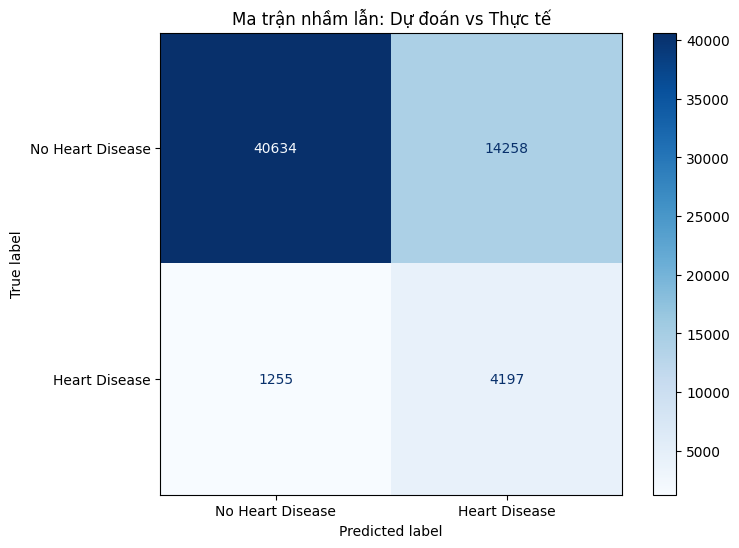

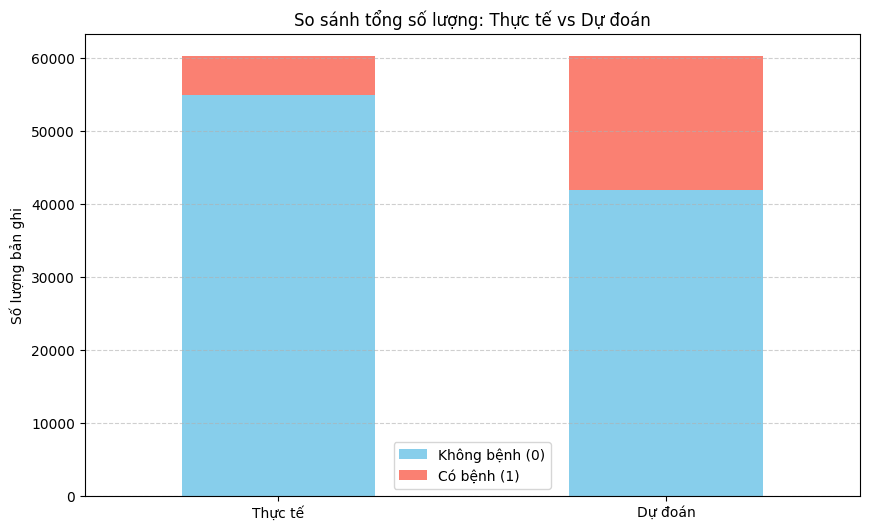

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Sử dụng mô hình Logistic Regression với class_weight='balanced' để đánh giá
model_eval = LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs')
model_eval.fit(X_train_80_s, y_train_80)
y_pred = model_eval.predict(X_test_20_s)

# 1. Vẽ Ma trận nhầm lẫn
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test_20, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Heart Disease', 'Heart Disease'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Ma trận nhầm lẫn: Dự đoán vs Thực tế')
plt.show()

# 2. So sánh tổng lượng Dự đoán và Thực tế
results_df = pd.DataFrame({'Thực tế': y_test_20, 'Dự đoán': y_pred})
comparison = results_df.apply(pd.Series.value_counts).T

ax_comp = comparison.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('So sánh tổng số lượng: Thực tế vs Dự đoán')
plt.ylabel('Số lượng bản ghi')
plt.xticks(rotation=0)
plt.legend(['Không bệnh (0)', 'Có bệnh (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

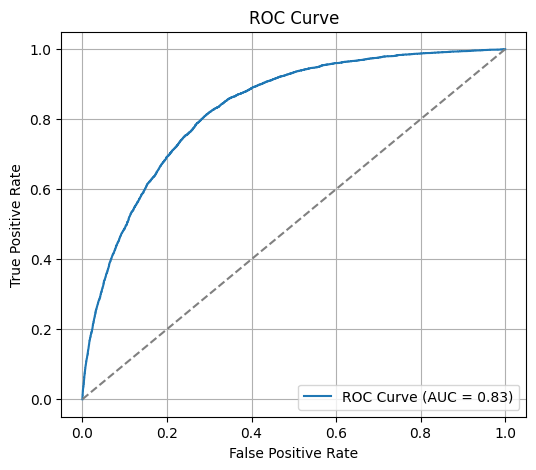

In [100]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Tính toán xác suất dự đoán (probability scores) thay vì nhãn (0/1)
y_proba = model_eval.predict_proba(X_test_20_s)[:, 1]

# 2. Tính toán FPR, TPR cho đường cong ROC
fpr, tpr, _ = roc_curve(y_test_20, y_proba)
auc_score = roc_auc_score(y_test_20, y_proba)

# 3. Vẽ biểu đồ
plt.figure(figsize = (6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()